# Main

In [1]:
import pandas as pd
import numpy as np
import time
import ast
import shap
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.inspection import permutation_importance
import concurrent.futures

In [2]:
def load_data(csv_path):
    df = pd.read_csv(csv_path)
    #df = df[:-5].copy() #last row is corrupted for the hyena 160/450k models
    initial_count = len(df)
    df = df.dropna(subset=['embedding'])
    removed_count = initial_count - len(df)

    try:
        X = np.array([ast.literal_eval(emb) for emb in df['embedding']])
        print(f"Removed {removed_count} rows with NaN values.")
    except (ValueError, SyntaxError) as e:
        print(f"Error parsing embeddings: {e}")
        print("Please check the format of your embedding strings.")
        raise
    
    #df["embedding"] = df["embedding"].apply(lambda x: np.fromstring(x[1:-1], dtype=float, sep=', ')) #cause like the genius I am, I've stored the embeddings as strings??
    #X = np.array(df["embedding"].to_numpy())

    y = df["label"].values

    return X, y

In [3]:
def train_classifier(X, y, test_size):
    """Train a Random Forest classifier on the embeddings."""
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=42, stratify=y)
    
    clf = RandomForestClassifier(n_estimators=100, random_state=42)
    clf.fit(X_train, y_train)
    
    return clf, X_train, X_test, y_train, y_test

In [4]:
def evaluate_model(clf, X_test, y_test):
    """Evaluate the classifier's performance."""
    y_pred = clf.predict(X_test)
    
    print("Accuracy:", accuracy_score(y_test, y_pred) * 100, "%")
    print(classification_report(y_test, y_pred))
    return accuracy_score(y_test, y_pred)

In [5]:
def plot_feature_importance(clf, name):
    """Plot the top 20 most important features using Random Forest's built-in feature importance."""
    feature_importance = clf.feature_importances_
    
    top_indices = np.argsort(feature_importance)[-20:]

    """
    plt.figure(figsize=(10, 5))
    plt.barh(range(20), feature_importance[top_indices], tick_label=[f"dim_{i}" for i in top_indices])
    plt.xlabel("Feature Importance")
    plt.ylabel("Embedding Dimension")
    plt.title(f"Top 20 Important Embedding Indices for {name}")
    plt.show()
    """

    return top_indices[:5]

In [6]:
def plot_shap_importance(clf, X_test, name): #abridged from https://medium.com/biased-algorithms/shap-values-for-random-forest-1150577563c9
    """Use SHAP to analyze feature importance."""
    explainer = shap.TreeExplainer(clf)
    shap_values = explainer.shap_values(X_test)
    print(shap_values.shape)
    shap.summary_plot(shap_values, X_test, feature_names=[f"dim_{i}" for i in range(X_test.shape[1])])

In [7]:
def classify(csv_path, test_size=0.2):
    filename = csv_path.split('\\')[-1]
    name = filename.split('_')[0]
    
    print(f"\nNow starting with: {name}\n")
    X, y = load_data(csv_path)

    clf, X_train, X_test, y_train, y_test = train_classifier(X, y, test_size)

    accuracy = evaluate_model(clf, X_test, y_test)

    top_features = plot_feature_importance(clf, name)

    """
    print("Plotting feature importance (Permutation Importance)...")
    plot_permutation_importance(clf, X_test, y_test)
    
    print("Plotting feature importance (SHAP)...")
    plot_shap_importance(clf, X_test, name)
    """

    print(f"Done with {name}.")

    return name, accuracy, top_features

# Model Accuracy Stem Plots

In [8]:
def main(split):
    x, y = [], []
    for filename in Path("GB_sequence_embeddings").glob("*.csv"):    
        name, accuracy, top_features = classify(str(filename), split)
        x.append(name)
        y.append(accuracy)
        print("Top 5 features:", top_features)
    """
    y_indices = np.argsort(x)
    x_sorted, y_sorted = sorted(x), []
    for index in y_indices:
        y_sorted.append(y[index])
    return x_sorted, y_sorted
    """
    return x, y

In [9]:
def stem_plotter(x, y, split):
    fig, ax = plt.subplots(1, 1, figsize = (12, 6))
    """
    ax.set_title(
        f"Random Forest Classifier Accuracy: Train - Test split of {int((1-split)*100)}% - {int((split)*100)}%",
        fontsize=12,
    )
    """
    ax.stem(x, y, 'black')
    ax.set(ylim=(0, 1))
    ax.axhline(0.5, color='#fc8d62', linestyle='--', linewidth=1)
    plt.ylabel("Accuracy", fontsize=12)
    plt.xlabel("Genomic Language Model", fontsize=12)
    plt.xticks(rotation=20, ha="right", fontsize=10)
    plt.show()

In [21]:
x2, y2 = main(0.25)


Now starting with: gena-lm-bigbird-base-t2t

Removed 0 rows with NaN values.
Accuracy: 91.732 %
              precision    recall  f1-score   support

           0       0.92      0.92      0.92     12500
           1       0.92      0.92      0.92     12500

    accuracy                           0.92     25000
   macro avg       0.92      0.92      0.92     25000
weighted avg       0.92      0.92      0.92     25000

Done with gena-lm-bigbird-base-t2t.
Top 5 features: [759   7 699 537 395]

Now starting with: gpn-brassicales

Removed 0 rows with NaN values.
Accuracy: 92.684 %
              precision    recall  f1-score   support

           0       0.94      0.91      0.93     12500
           1       0.91      0.94      0.93     12500

    accuracy                           0.93     25000
   macro avg       0.93      0.93      0.93     25000
weighted avg       0.93      0.93      0.93     25000

Done with gpn-brassicales.
Top 5 features: [102 160 310 193  12]

Now starting with: GR

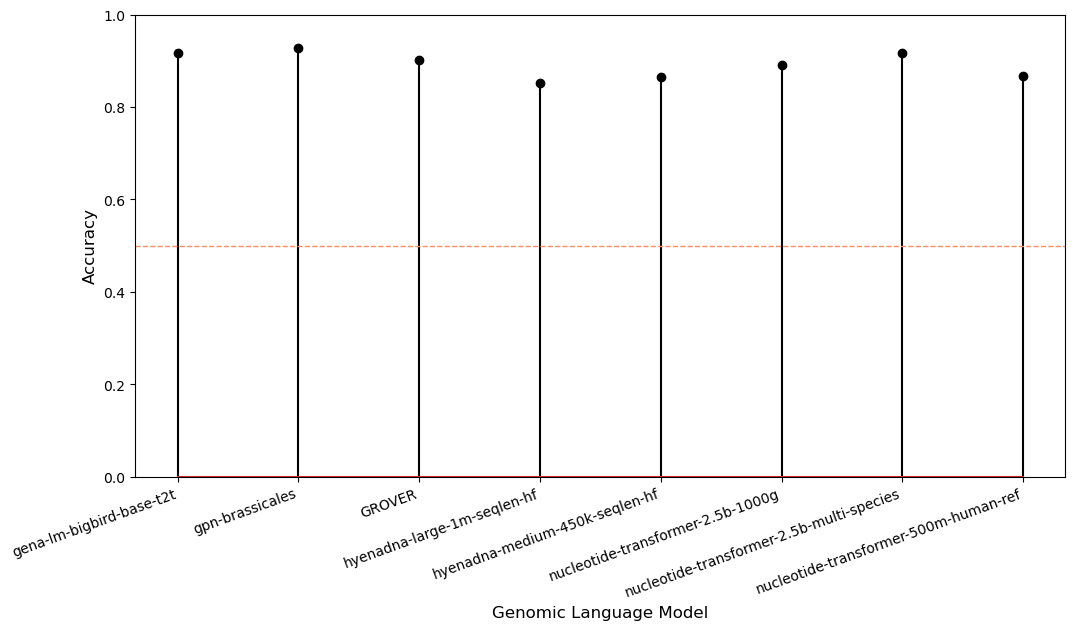

In [23]:
stem_plotter(x2, y2, 0.75)

In [10]:
x99, y99 = main(0.99)


Now starting with: gena-lm-bigbird-base-t2t

Removed 0 rows with NaN values.
Accuracy: 90.27272727272727 %
              precision    recall  f1-score   support

           0       0.90      0.90      0.90     49500
           1       0.90      0.90      0.90     49500

    accuracy                           0.90     99000
   macro avg       0.90      0.90      0.90     99000
weighted avg       0.90      0.90      0.90     99000

Done with gena-lm-bigbird-base-t2t.
Top 5 features: [439 387 537  43 566]

Now starting with: gpn-brassicales

Removed 0 rows with NaN values.
Accuracy: 90.97878787878788 %
              precision    recall  f1-score   support

           0       0.92      0.90      0.91     49500
           1       0.90      0.92      0.91     49500

    accuracy                           0.91     99000
   macro avg       0.91      0.91      0.91     99000
weighted avg       0.91      0.91      0.91     99000

Done with gpn-brassicales.
Top 5 features: [ 34 127 102 418 363]


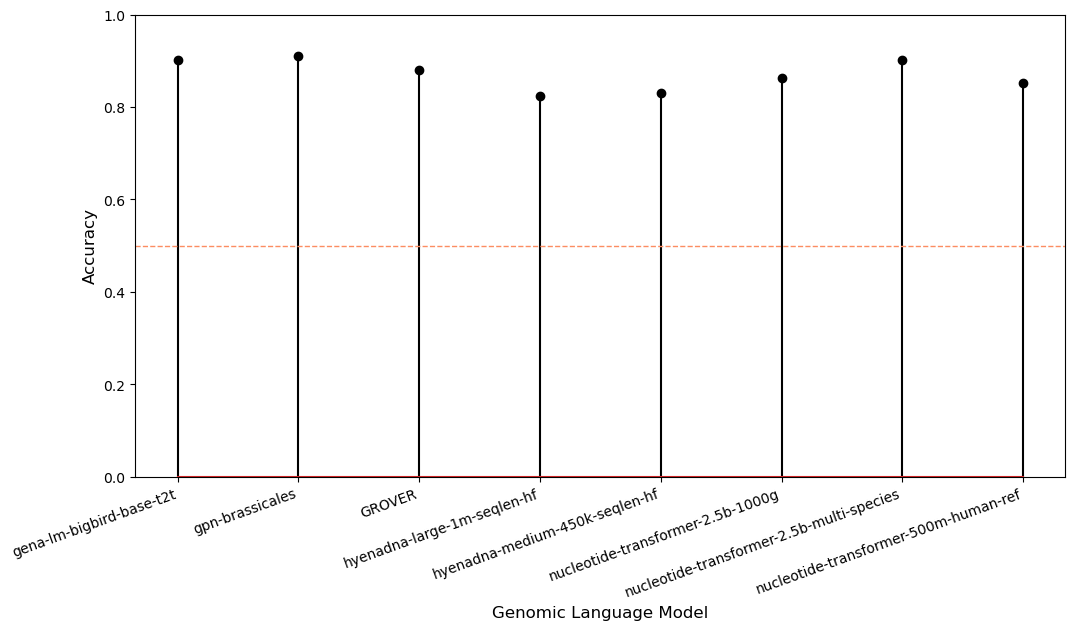

In [11]:
stem_plotter(x99, y99, 0.99)

In [10]:
x9999, y9999 = main(0.9999)


Now starting with: gena-lm-bigbird-base-t2t

Removed 0 rows with NaN values.
Accuracy: 83.36333633363337 %
              precision    recall  f1-score   support

           0       0.89      0.76      0.82     49995
           1       0.79      0.91      0.85     49995

    accuracy                           0.83     99990
   macro avg       0.84      0.83      0.83     99990
weighted avg       0.84      0.83      0.83     99990

Done with gena-lm-bigbird-base-t2t.
Top 5 features: [287 283 244 517 177]

Now starting with: gpn-brassicales

Removed 0 rows with NaN values.
Accuracy: 88.34983498349835 %
              precision    recall  f1-score   support

           0       0.86      0.91      0.89     49995
           1       0.91      0.85      0.88     49995

    accuracy                           0.88     99990
   macro avg       0.88      0.88      0.88     99990
weighted avg       0.88      0.88      0.88     99990

Done with gpn-brassicales.
Top 5 features: [412 421 367 200 458]


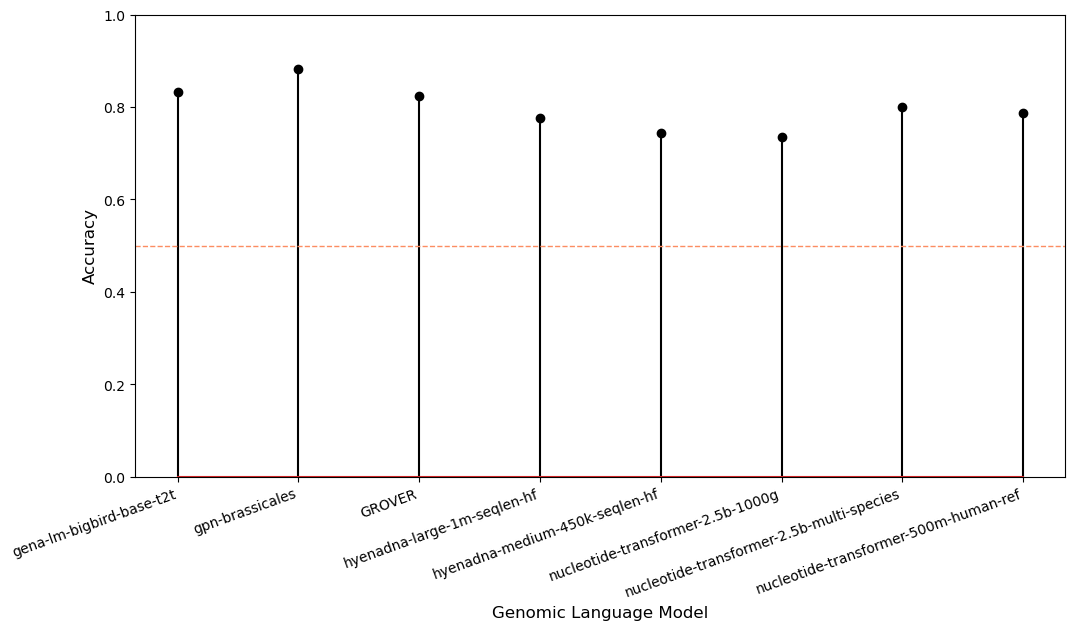

In [11]:
stem_plotter(x9999, y9999, 0.9999)

direct kmeans clustering and then see ARI with respect to actual sequence type
try spectral/DBSCAN/hierarchical too

check other DS tasks which we can do this same kind of classification analysis on

# Clustering ARI Verification (K-Means, DBSCAN, Birch)
Evaluate whether unsupervised clusters align with coding vs intergenic labels across all embedding models.

In [10]:
from sklearn.cluster import KMeans, Birch, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score
from sklearn.preprocessing import StandardScaler

In [11]:
def clustering_metrics_for_embeddings(
    X,
    y,
    random_state=42,
    dbscan_sample_size=5000,
    dbscan_eps=2.5,
    dbscan_min_samples=10
):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    results = {}

    kmeans = KMeans(n_clusters=2, random_state=random_state, n_init=20)
    kmeans_labels = kmeans.fit_predict(X_scaled)
    results["KMeans ARI"] = adjusted_rand_score(y, kmeans_labels)

    '''
    birch = Birch(n_clusters=2)
    birch_labels = birch.fit_predict(X_scaled)
    results["Birch ARI"] = adjusted_rand_score(y, birch_labels)
    '''

    return results

In [13]:
def run_clustering_ari_benchmark(folder="GB_sequence_embeddings", dbscan_sample_size=5000):
    rows = []
    for filename in sorted(Path(folder).glob("*.csv")):
        model_name = filename.stem.split("_")[0]
        print(f"\nEvaluating clustering for: {model_name}")
        X, y = load_data(str(filename))
        metrics = clustering_metrics_for_embeddings(
            X,
            y,
            dbscan_sample_size=dbscan_sample_size
        )

        row = {"Model": model_name}
        row.update(metrics)
        rows.append(row)

        print(
            f"KMeans ARI={metrics['KMeans ARI']:.4f}"
        )

    '''
    f"Birch ARI={metrics['Birch ARI']:.4f} | "
    '''

    return pd.DataFrame(rows).sort_values("Model").reset_index(drop=True)

clustering_ari_results = run_clustering_ari_benchmark(dbscan_sample_size=5000)
clustering_ari_results


Evaluating clustering for: gena-lm-bigbird-base-t2t
Removed 0 rows with NaN values.
KMeans ARI=0.2652

Evaluating clustering for: gpn-brassicales
Removed 0 rows with NaN values.
KMeans ARI=0.5685

Evaluating clustering for: GROVER
Removed 0 rows with NaN values.
KMeans ARI=0.3727

Evaluating clustering for: hyenadna-large-1m-seqlen-hf
Removed 0 rows with NaN values.
KMeans ARI=0.2085

Evaluating clustering for: hyenadna-medium-450k-seqlen-hf
Removed 0 rows with NaN values.
KMeans ARI=0.2076

Evaluating clustering for: nucleotide-transformer-2.5b-1000g
Removed 0 rows with NaN values.
KMeans ARI=0.2081

Evaluating clustering for: nucleotide-transformer-2.5b-multi-species
Removed 0 rows with NaN values.
KMeans ARI=-0.0000

Evaluating clustering for: nucleotide-transformer-500m-human-ref
Removed 0 rows with NaN values.
KMeans ARI=0.3315


,Model,KMeans ARI
0,GROVER,0.372656
1,gena-lm-bigbird-base-t2t,0.265219
2,gpn-brassicales,0.568512
3,hyenadna-large-1m-seqlen-hf,0.208476
4,hyenadna-medium-450k-seqlen-hf,0.207619
5,nucleotide-transformer-2.5b-1000g,0.208057
6,nucleotide-transformer-2.5b-multi-species,-0.000007
7,nucleotide-transformer-500m-human-ref,0.331493


In [1]:
def clustering_ari_stem_plot(results_df):
    models = results_df["Model"].tolist()
    x = np.arange(len(models))

    fig, ax = plt.subplots(1, 1, figsize=(14, 6))
    ax.stem(
        x - 0.2,
        results_df["KMeans ARI"],
        linefmt="C0-",
        markerfmt="C0o",
        basefmt=" ",
        label="K-Means"
    )
    """
    ax.stem(
        x,
        results_df["Birch ARI"],
        linefmt="C1-",
        markerfmt="C1s",
        basefmt=" ",
        label="Birch"
    )
    ax.stem(
        x + 0.2,
        results_df["DBSCAN ARI"],
        linefmt="C2-",
        markerfmt="C2^",
        basefmt=" ",
        label="DBSCAN (sampled)"
    )
    """
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=20, ha="right")
    ax.set_ylim(-0.05, 1.05)
    ax.axhline(0.0, color="gray", linestyle="--", linewidth=1)
    ax.set_ylabel("Adjusted Rand Index (ARI)")
    ax.set_xlabel("Genomic Language Model")
    ax.set_title("Clustering Alignment with True Labels")
    ax.legend()
    plt.tight_layout()
    plt.show()

clustering_ari_stem_plot(clustering_ari_results)

NameError: name 'clustering_ari_results' is not defined

# UMAP Viz:

In [10]:
import umap
import seaborn as sns

In [11]:
def U_MAP(embeddings):
    params = {
        "random_state": 42,
        #"n_neighbors": 17,
        #"n_epochs": None,
        # "learning_rate": 0.01,
        "min_dist": 5,
        "spread": 10,
        # "metric": "manhattan",
    }
    # Adapted from https://umap-learn.readthedocs.io/en/latest/basic_usage.html
    reducer = umap.UMAP(**params)
    umapResults = reducer.fit_transform(embeddings)

    return umapResults, params

In [12]:
def UMAPplotter(model, df):
    results, params = U_MAP([[0]])
    columns = ["UMAP1", "UMAP2"]

    fig, ax = plt.subplots(figsize=(8, 8))
    sns.set_style("darkgrid", {"grid.color": ".6", "grid.linestyle": ":"})
    sns.scatterplot(data=df, x=columns[0], y=columns[1], hue="Gene Type", palette="hls", alpha=0.25)
    # sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
    plt.legend(title="Sequence Type", fontsize=8, title_fontsize=9, bbox_to_anchor=(1, 1))
    plt.title(
        f"Scatter plot of {model}'s human gene embeddings using UMAP reduction"
    )
    plt.xlabel(columns[0])
    plt.ylabel(columns[1])
    #ax.set_xlim(-100, 100)
    #ax.set_ylim(-100, 100)

    # plt.axis("equal")

    plt.show()

In [ ]:
for filename in Path("GB_sequence_embeddings").glob("*.csv"):    
    embeddings, labels = load_data(str(filename))
    file = str(filename).split('\\')[-1]
    name = file.split('_')[0]
    umapResults, params = U_MAP(embeddings)
    singleGeneDF = pd.DataFrame(umapResults, columns = ["UMAP1", "UMAP2"])
    singleGeneDF["Gene Type"] = labels
    UMAPplotter(name, singleGeneDF)

viz in 3D UMAP
biotite translation tool - uses a codon matrix 

3 ORFS starting from 1st second and 3rd nucleotide of each coding sequence
for each of these sets of ORFS, then mutate 1st second and third nucleotides.

Removed 0 rows with NaN values.


c:\Users\Ruhaib\anaconda3\envs\eval\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\Ruhaib\anaconda3\envs\eval\Lib\site-packages\umap\umap_.py:1394: RuntimeWarning: divide by zero encountered in power
  return 1.0 / (1.0 + a * x ** (2 * b))
c:\Users\Ruhaib\anaconda3\envs\eval\Lib\site-packages\umap\umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")
c:\Users\Ruhaib\anaconda3\envs\eval\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\Ruhaib\anaconda3\envs\eval\Lib\site-packages\umap\umap_.py:1394: RuntimeWarning: divide by zero encountered in power
  return 1

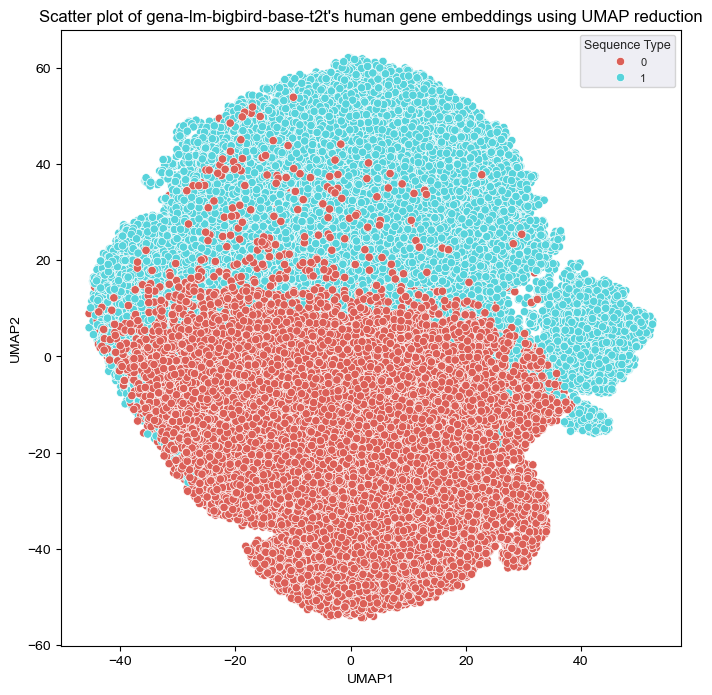

Removed 0 rows with NaN values.


c:\Users\Ruhaib\anaconda3\envs\eval\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\Ruhaib\anaconda3\envs\eval\Lib\site-packages\umap\umap_.py:1394: RuntimeWarning: divide by zero encountered in power
  return 1.0 / (1.0 + a * x ** (2 * b))
c:\Users\Ruhaib\anaconda3\envs\eval\Lib\site-packages\umap\umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")
c:\Users\Ruhaib\anaconda3\envs\eval\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\Ruhaib\anaconda3\envs\eval\Lib\site-packages\umap\umap_.py:1394: RuntimeWarning: divide by zero encountered in power
  return 1

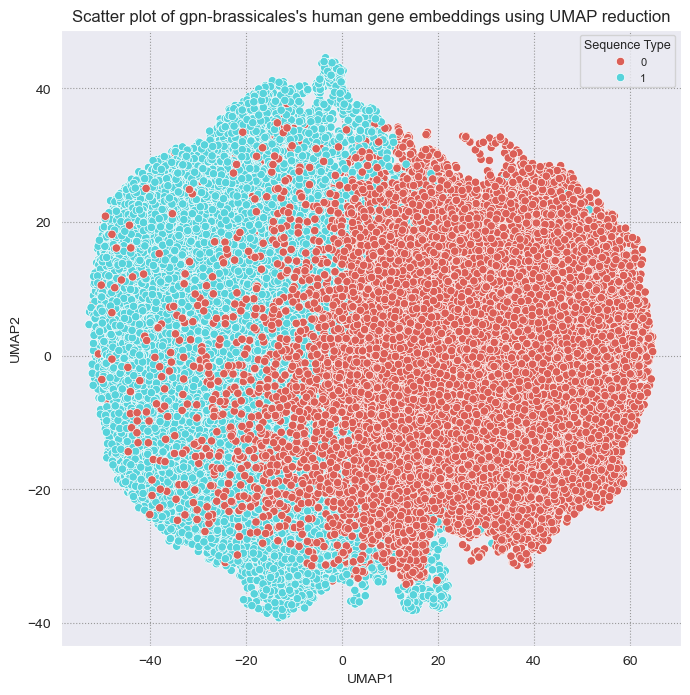

Removed 0 rows with NaN values.


c:\Users\Ruhaib\anaconda3\envs\eval\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\Ruhaib\anaconda3\envs\eval\Lib\site-packages\umap\umap_.py:1394: RuntimeWarning: divide by zero encountered in power
  return 1.0 / (1.0 + a * x ** (2 * b))
c:\Users\Ruhaib\anaconda3\envs\eval\Lib\site-packages\umap\umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")
c:\Users\Ruhaib\anaconda3\envs\eval\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\Ruhaib\anaconda3\envs\eval\Lib\site-packages\umap\umap_.py:1394: RuntimeWarning: divide by zero encountered in power
  return 1

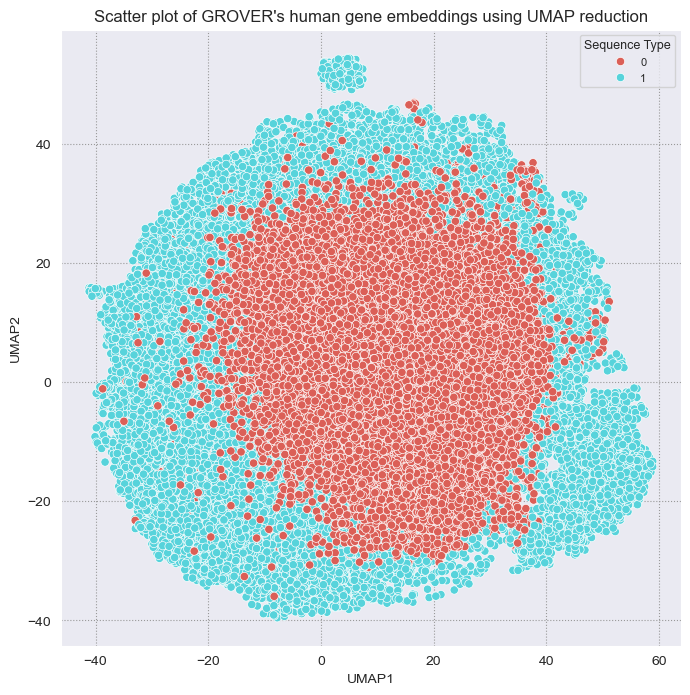

Removed 0 rows with NaN values.


c:\Users\Ruhaib\anaconda3\envs\eval\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\Ruhaib\anaconda3\envs\eval\Lib\site-packages\umap\umap_.py:1394: RuntimeWarning: divide by zero encountered in power
  return 1.0 / (1.0 + a * x ** (2 * b))
c:\Users\Ruhaib\anaconda3\envs\eval\Lib\site-packages\umap\umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")
c:\Users\Ruhaib\anaconda3\envs\eval\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\Ruhaib\anaconda3\envs\eval\Lib\site-packages\umap\umap_.py:1394: RuntimeWarning: divide by zero encountered in power
  return 1

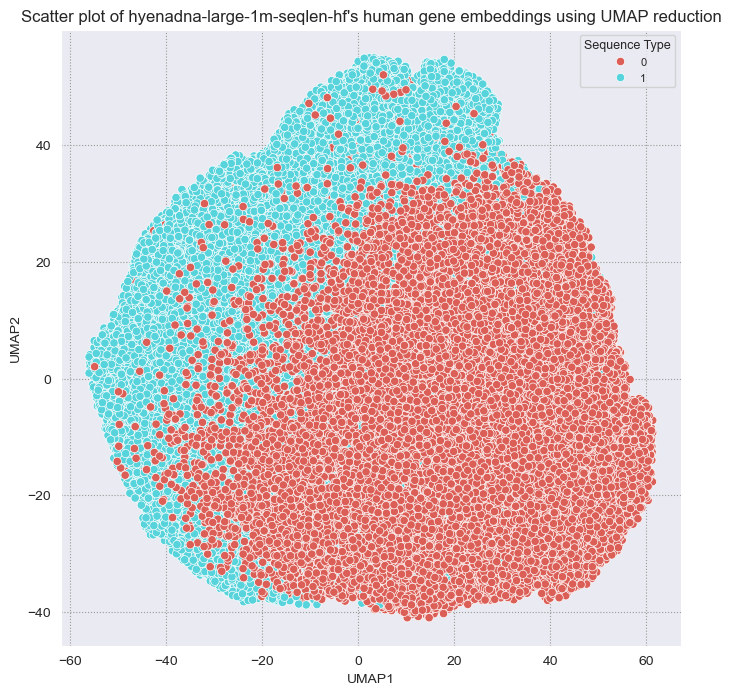

Removed 0 rows with NaN values.


c:\Users\Ruhaib\anaconda3\envs\eval\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\Ruhaib\anaconda3\envs\eval\Lib\site-packages\umap\umap_.py:1394: RuntimeWarning: divide by zero encountered in power
  return 1.0 / (1.0 + a * x ** (2 * b))
c:\Users\Ruhaib\anaconda3\envs\eval\Lib\site-packages\umap\umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")
c:\Users\Ruhaib\anaconda3\envs\eval\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\Ruhaib\anaconda3\envs\eval\Lib\site-packages\umap\umap_.py:1394: RuntimeWarning: divide by zero encountered in power
  return 1

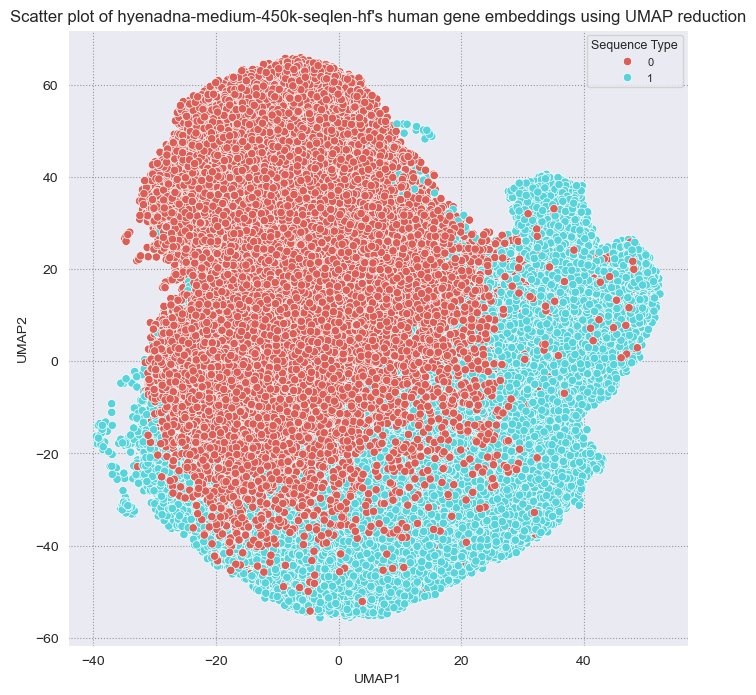

Removed 0 rows with NaN values.


c:\Users\Ruhaib\anaconda3\envs\eval\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\Ruhaib\anaconda3\envs\eval\Lib\site-packages\umap\umap_.py:1394: RuntimeWarning: divide by zero encountered in power
  return 1.0 / (1.0 + a * x ** (2 * b))
c:\Users\Ruhaib\anaconda3\envs\eval\Lib\site-packages\umap\umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")
c:\Users\Ruhaib\anaconda3\envs\eval\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\Ruhaib\anaconda3\envs\eval\Lib\site-packages\umap\umap_.py:1394: RuntimeWarning: divide by zero encountered in power
  return 1

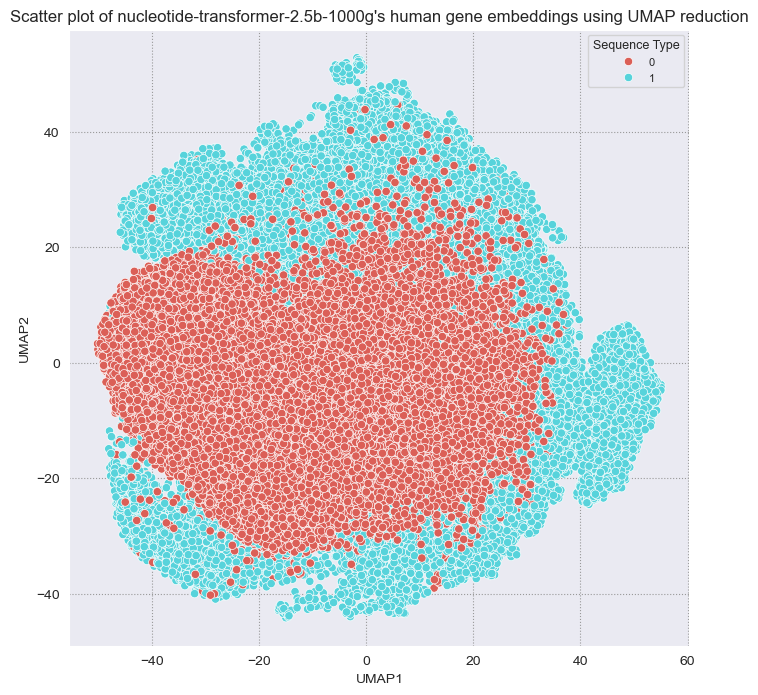

In [ ]:
for filename in Path("GB_sequence_embeddings").glob("*.csv"):    
    embeddings, labels = load_data(str(filename))
    file = str(filename).split('\\')[-1]
    name = file.split('_')[0]
    umapResults, params = U_MAP(embeddings)
    singleGeneDF = pd.DataFrame(umapResults, columns = ["UMAP1", "UMAP2"])
    singleGeneDF["Gene Type"] = labels
    UMAPplotter(name, singleGeneDF)

# Zero-shot Predictions:


Now starting with: DNABERT-S

Loading data...
Removed 2 rows with NaN values.
Training classifier...
Evaluating model...
Accuracy: 60.11687363038715 %
              precision    recall  f1-score   support

      Coding       0.52      0.17      0.26      7207
  Non-coding       0.61      0.89      0.73     10590

    accuracy                           0.60     17797
   macro avg       0.57      0.53      0.49     17797
weighted avg       0.58      0.60      0.54     17797

Plotting feature importance (Random Forest)...


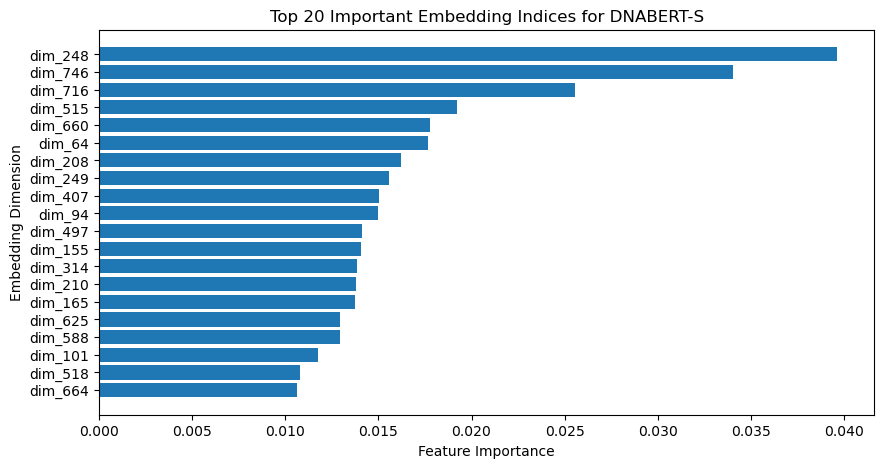


Now starting with: GenaLM

Loading data...
Removed 2 rows with NaN values.
Training classifier...
Evaluating model...
Accuracy: 75.6925324492892 %
              precision    recall  f1-score   support

      Coding       0.79      0.55      0.65      7207
  Non-coding       0.74      0.90      0.81     10590

    accuracy                           0.76     17797
   macro avg       0.77      0.72      0.73     17797
weighted avg       0.76      0.76      0.75     17797

Plotting feature importance (Random Forest)...


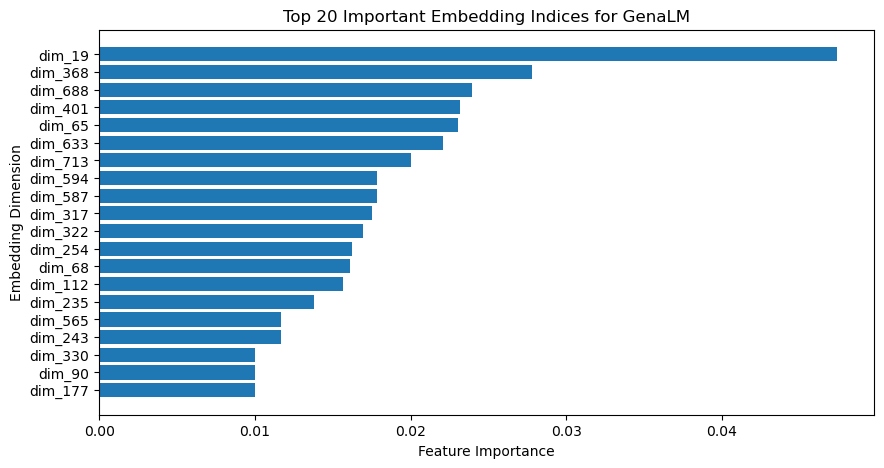


Now starting with: GPN

Loading data...
Removed 0 rows with NaN values.
Training classifier...
Evaluating model...
Accuracy: 58.67511161873118 %
              precision    recall  f1-score   support

      Coding       0.60      0.61      0.60     19785
  Non-coding       0.58      0.57      0.57     18739

    accuracy                           0.59     38524
   macro avg       0.59      0.59      0.59     38524
weighted avg       0.59      0.59      0.59     38524

Plotting feature importance (Random Forest)...


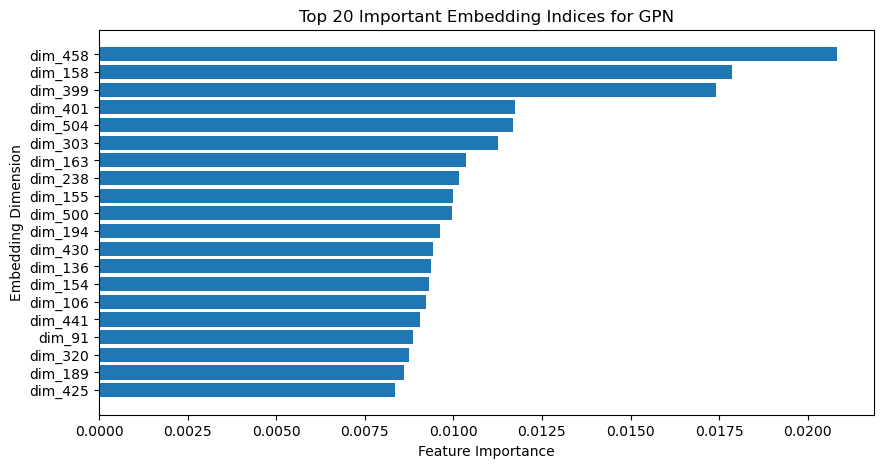


Now starting with: GROVER

Loading data...
Removed 0 rows with NaN values.
Training classifier...
Evaluating model...
Accuracy: 61.92788439198922 %
              precision    recall  f1-score   support

      Coding       0.63      0.74      0.68     23289
  Non-coding       0.61      0.48      0.54     19753

    accuracy                           0.62     43042
   macro avg       0.62      0.61      0.61     43042
weighted avg       0.62      0.62      0.61     43042

Plotting feature importance (Random Forest)...


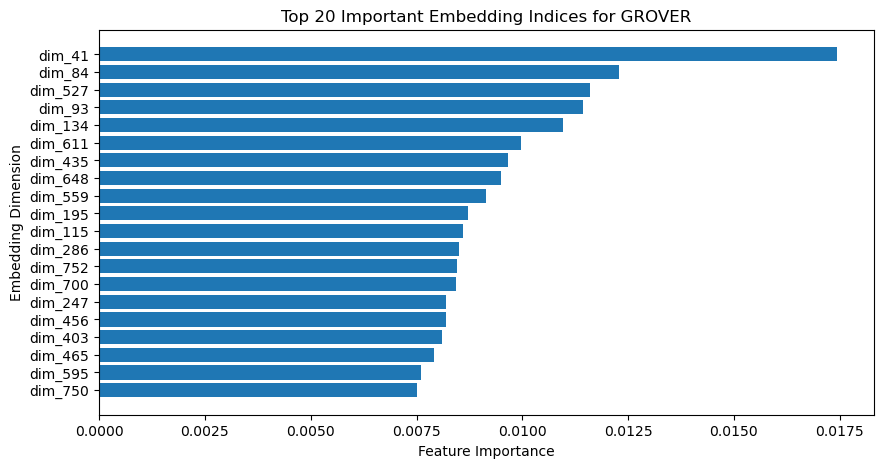


Now starting with: Hyena-160k

Loading data...
Removed 4 rows with NaN values.
Training classifier...
Evaluating model...
Accuracy: 55.27750376408286 %
              precision    recall  f1-score   support

      Coding       0.56      0.61      0.58     19784
  Non-coding       0.54      0.49      0.52     18738

    accuracy                           0.55     38522
   macro avg       0.55      0.55      0.55     38522
weighted avg       0.55      0.55      0.55     38522

Plotting feature importance (Random Forest)...


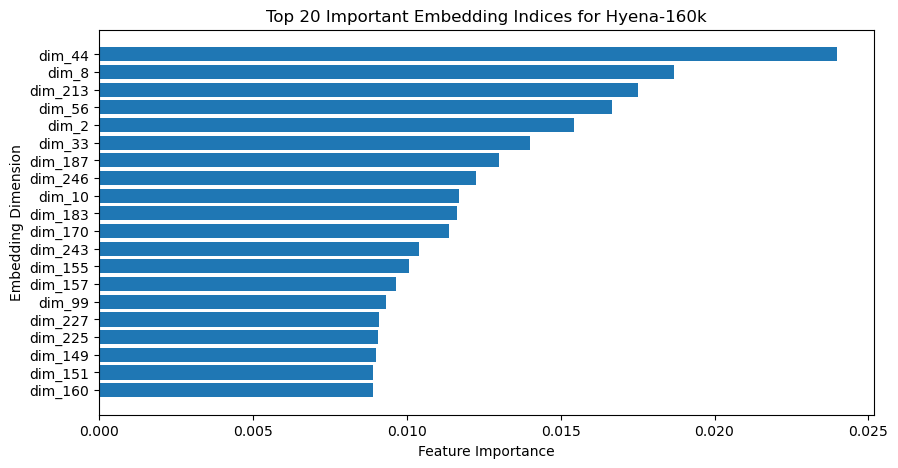


Now starting with: Hyena-16k

Loading data...
Removed 0 rows with NaN values.
Training classifier...
Evaluating model...
Accuracy: 58.5567585149389 %
              precision    recall  f1-score   support

      Coding       0.60      0.69      0.64     23289
  Non-coding       0.56      0.46      0.50     19753

    accuracy                           0.59     43042
   macro avg       0.58      0.58      0.57     43042
weighted avg       0.58      0.59      0.58     43042

Plotting feature importance (Random Forest)...


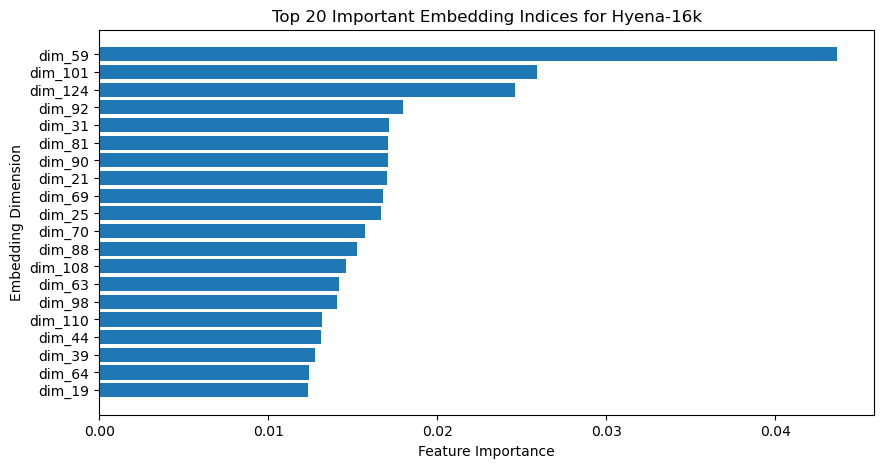


Now starting with: Hyena-1k

Loading data...
Removed 0 rows with NaN values.
Training classifier...
Evaluating model...
Accuracy: 59.6301287114911 %
              precision    recall  f1-score   support

      Coding       0.60      0.78      0.68     23289
  Non-coding       0.59      0.38      0.47     19753

    accuracy                           0.60     43042
   macro avg       0.60      0.58      0.57     43042
weighted avg       0.60      0.60      0.58     43042

Plotting feature importance (Random Forest)...


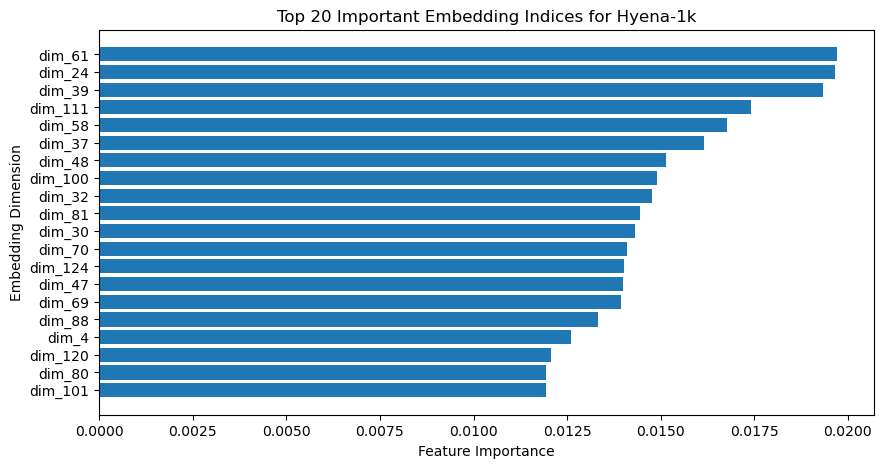


Now starting with: Hyena-32k

Loading data...
Removed 0 rows with NaN values.
Training classifier...
Evaluating model...
Accuracy: 55.95472951926072 %
              precision    recall  f1-score   support

      Coding       0.56      0.64      0.60     19785
  Non-coding       0.55      0.48      0.51     18739

    accuracy                           0.56     38524
   macro avg       0.56      0.56      0.56     38524
weighted avg       0.56      0.56      0.56     38524

Plotting feature importance (Random Forest)...


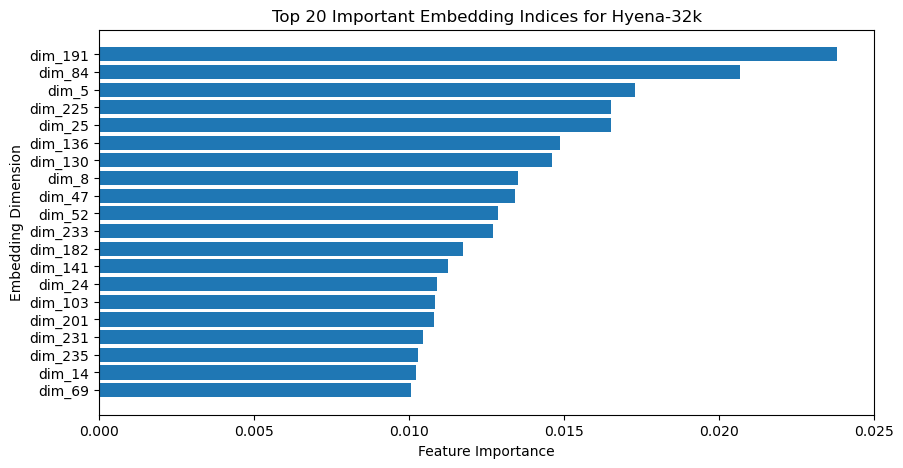


Now starting with: Hyena-450k

Loading data...
Removed 4 rows with NaN values.
Training classifier...
Evaluating model...
Accuracy: 54.9608016198536 %
              precision    recall  f1-score   support

      Coding       0.55      0.69      0.61     19784
  Non-coding       0.55      0.40      0.46     18738

    accuracy                           0.55     38522
   macro avg       0.55      0.55      0.54     38522
weighted avg       0.55      0.55      0.54     38522

Plotting feature importance (Random Forest)...


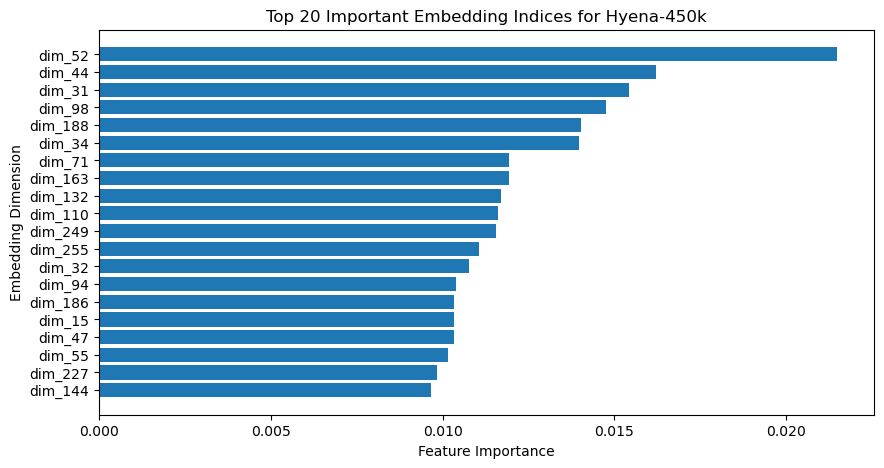


Now starting with: NT2.5B-1K

Loading data...
Removed 0 rows with NaN values.
Training classifier...
Evaluating model...
Accuracy: 100.0 %
              precision    recall  f1-score   support

      Coding       1.00      1.00      1.00      7207

    accuracy                           1.00      7207
   macro avg       1.00      1.00      1.00      7207
weighted avg       1.00      1.00      1.00      7207

Plotting feature importance (Random Forest)...


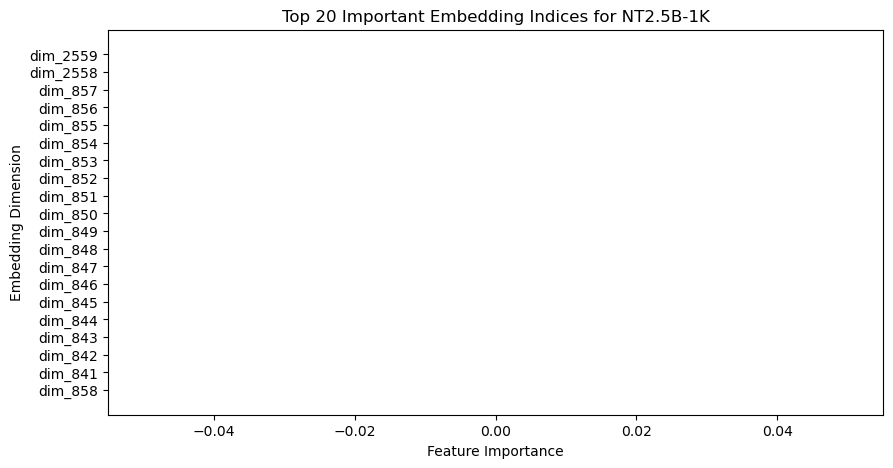


Now starting with: NT500M

Loading data...
Removed 0 rows with NaN values.
Training classifier...
Evaluating model...
Accuracy: 59.42103062125366 %
              precision    recall  f1-score   support

      Coding       0.60      0.76      0.67     23289
  Non-coding       0.59      0.40      0.47     19753

    accuracy                           0.59     43042
   macro avg       0.59      0.58      0.57     43042
weighted avg       0.59      0.59      0.58     43042

Plotting feature importance (Random Forest)...


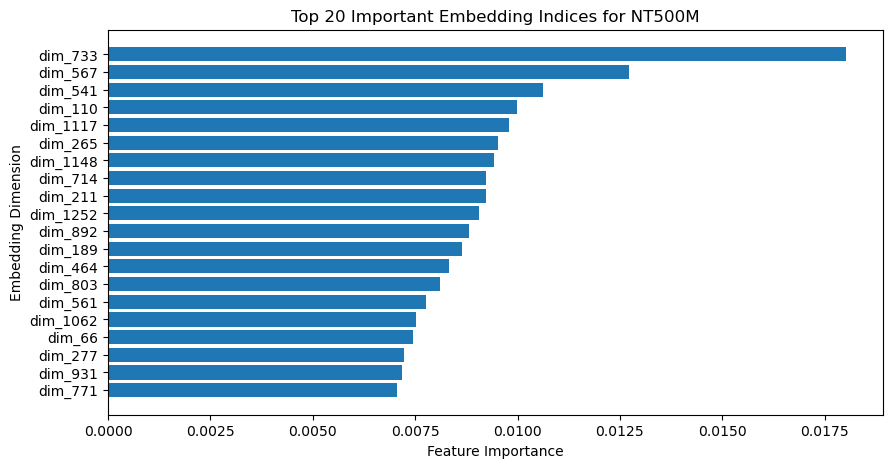

In [ ]:
for filename in Path("Coding-NonCoding").glob("*.csv"):    
    main(str(filename), 0.999)


Now starting with: DNABERT-S

Loading data...
Removed 2 rows with NaN values.
Training classifier...
Evaluating model...
Accuracy: 73.58780430158355 %
              precision    recall  f1-score   support

      Coding       0.74      0.53      0.62      6854
  Non-coding       0.73      0.87      0.80     10070

    accuracy                           0.74     16924
   macro avg       0.74      0.70      0.71     16924
weighted avg       0.74      0.74      0.73     16924

Plotting feature importance (Random Forest)...


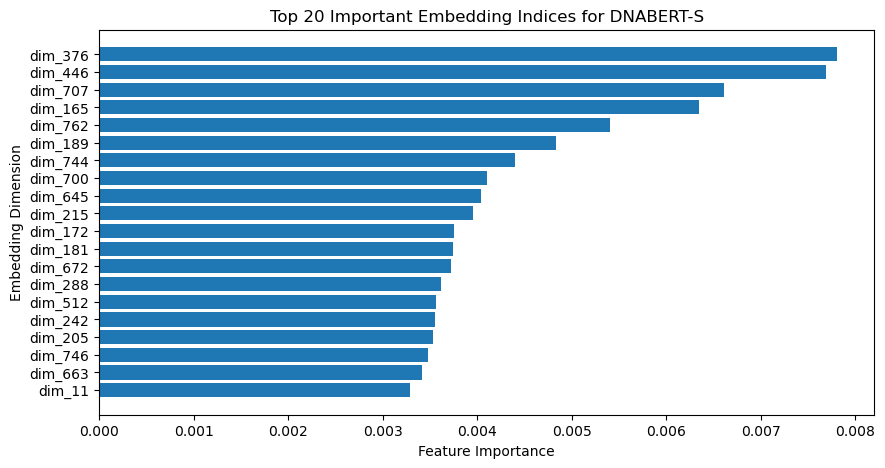


Now starting with: GenaLM

Loading data...
Removed 2 rows with NaN values.
Training classifier...
Evaluating model...
Accuracy: 85.0094540297802 %
              precision    recall  f1-score   support

      Coding       0.83      0.79      0.81      6854
  Non-coding       0.86      0.89      0.88     10070

    accuracy                           0.85     16924
   macro avg       0.85      0.84      0.84     16924
weighted avg       0.85      0.85      0.85     16924

Plotting feature importance (Random Forest)...


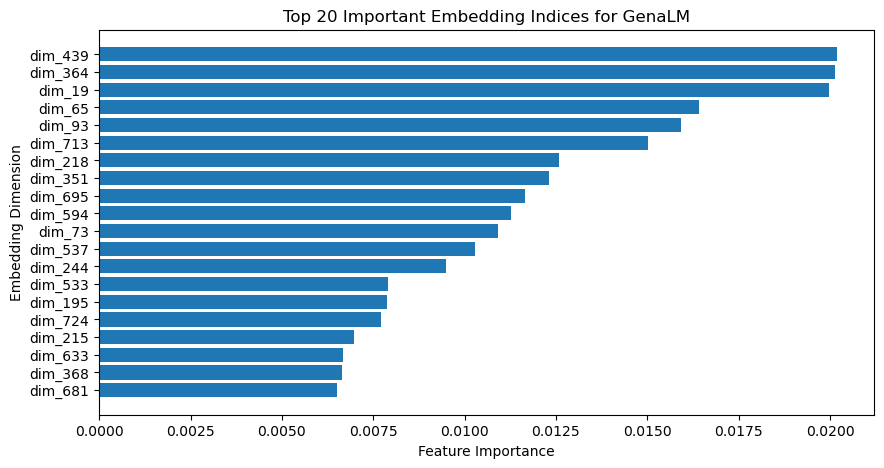


Now starting with: GPN

Loading data...
Removed 0 rows with NaN values.
Training classifier...
Evaluating model...
Accuracy: 75.52000873505487 %
              precision    recall  f1-score   support

      Coding       0.74      0.80      0.77     18815
  Non-coding       0.77      0.71      0.74     17819

    accuracy                           0.76     36634
   macro avg       0.76      0.75      0.75     36634
weighted avg       0.76      0.76      0.75     36634

Plotting feature importance (Random Forest)...


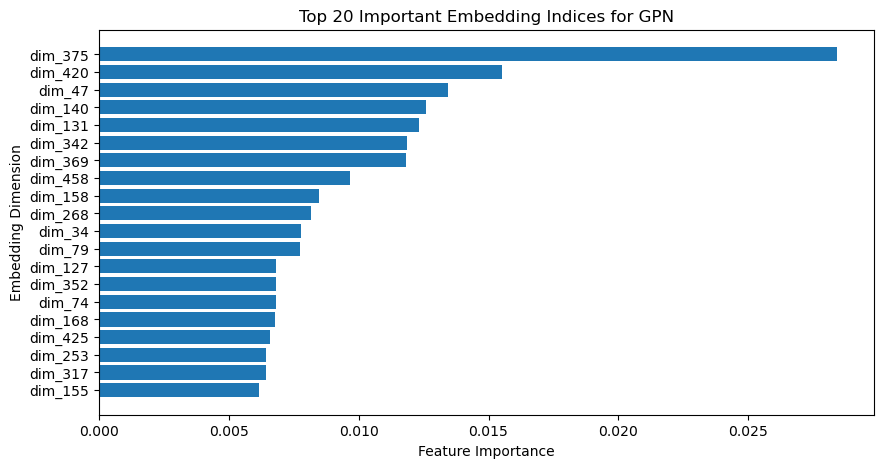


Now starting with: GROVER

Loading data...


Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x000001CDA28D2600>>
Traceback (most recent call last):
  File "c:\Users\Ruhaib\anaconda3\envs\eval\Lib\site-packages\ipykernel\ipkernel.py", line 790, in _clean_thread_parent_frames
    active_threads = {thread.ident for thread in threading.enumerate()}
                                                 ^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Ruhaib\anaconda3\envs\eval\Lib\threading.py", line 1533, in enumerate
    def enumerate():
    
KeyboardInterrupt: 


Removed 0 rows with NaN values.
Training classifier...
Evaluating model...
Accuracy: 72.2264298453495 %
              precision    recall  f1-score   support

      Coding       0.74      0.75      0.75     22147
  Non-coding       0.70      0.69      0.69     18784

    accuracy                           0.72     40931
   macro avg       0.72      0.72      0.72     40931
weighted avg       0.72      0.72      0.72     40931

Plotting feature importance (Random Forest)...


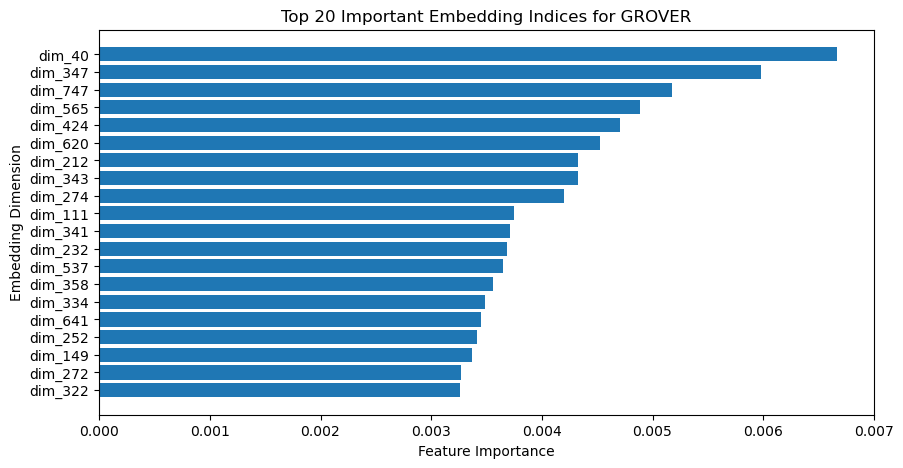


Now starting with: Hyena-160k

Loading data...
Removed 4 rows with NaN values.
Training classifier...
Evaluating model...
Accuracy: 71.27101987333478 %
              precision    recall  f1-score   support

      Coding       0.73      0.71      0.72     18814
  Non-coding       0.70      0.72      0.71     17818

    accuracy                           0.71     36632
   macro avg       0.71      0.71      0.71     36632
weighted avg       0.71      0.71      0.71     36632

Plotting feature importance (Random Forest)...


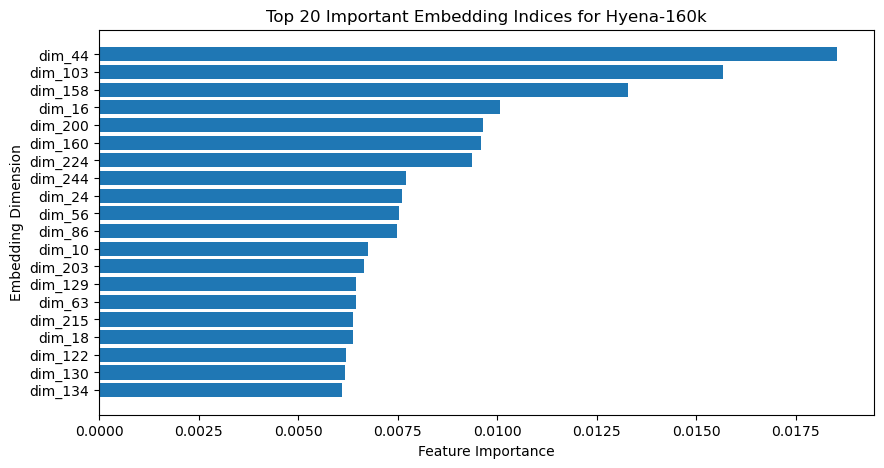


Now starting with: Hyena-16k

Loading data...
Removed 0 rows with NaN values.
Training classifier...
Evaluating model...
Accuracy: 70.27925044587232 %
              precision    recall  f1-score   support

      Coding       0.72      0.74      0.73     22147
  Non-coding       0.68      0.66      0.67     18784

    accuracy                           0.70     40931
   macro avg       0.70      0.70      0.70     40931
weighted avg       0.70      0.70      0.70     40931

Plotting feature importance (Random Forest)...


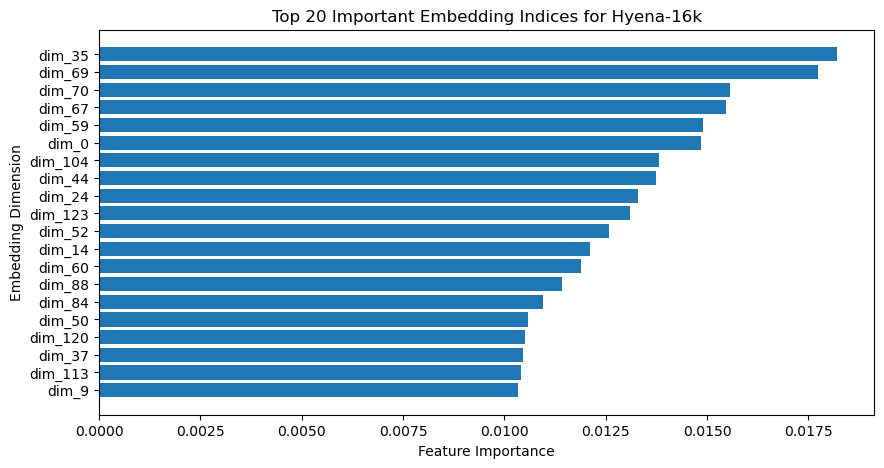


Now starting with: Hyena-1k

Loading data...
Removed 0 rows with NaN values.
Training classifier...
Evaluating model...
Accuracy: 67.953384964941 %
              precision    recall  f1-score   support

      Coding       0.69      0.73      0.71     22147
  Non-coding       0.66      0.62      0.64     18784

    accuracy                           0.68     40931
   macro avg       0.68      0.67      0.68     40931
weighted avg       0.68      0.68      0.68     40931

Plotting feature importance (Random Forest)...


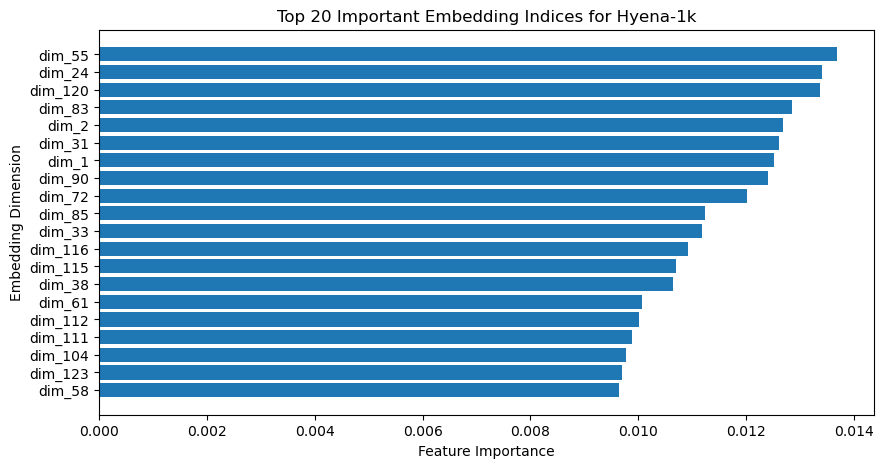


Now starting with: Hyena-32k

Loading data...
Removed 0 rows with NaN values.
Training classifier...
Evaluating model...
Accuracy: 69.63203581372495 %
              precision    recall  f1-score   support

      Coding       0.70      0.71      0.71     18815
  Non-coding       0.69      0.68      0.69     17819

    accuracy                           0.70     36634
   macro avg       0.70      0.70      0.70     36634
weighted avg       0.70      0.70      0.70     36634

Plotting feature importance (Random Forest)...


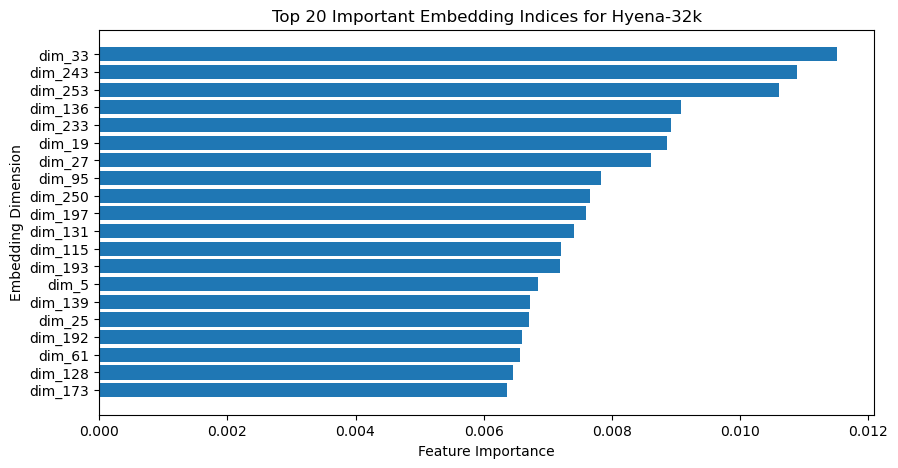


Now starting with: Hyena-450k

Loading data...
Removed 4 rows with NaN values.
Training classifier...
Evaluating model...
Accuracy: 72.35477178423237 %
              precision    recall  f1-score   support

      Coding       0.74      0.71      0.73     18814
  Non-coding       0.71      0.74      0.72     17818

    accuracy                           0.72     36632
   macro avg       0.72      0.72      0.72     36632
weighted avg       0.72      0.72      0.72     36632

Plotting feature importance (Random Forest)...


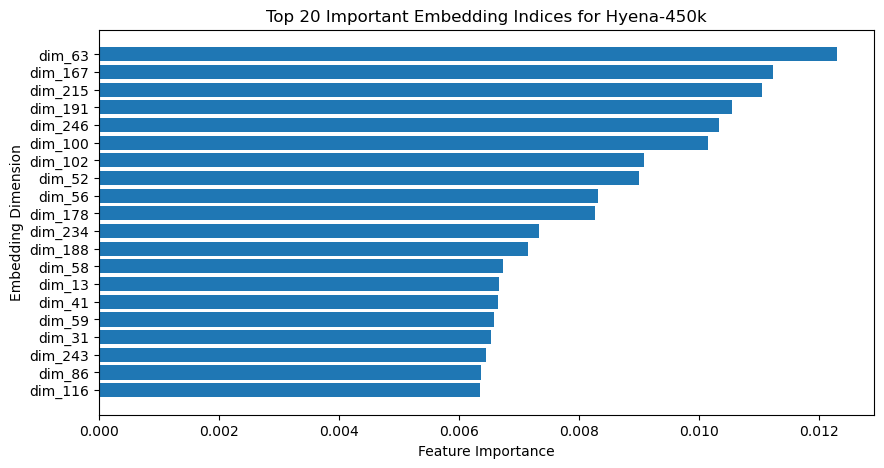


Now starting with: NT2.5B-1K

Loading data...
Removed 0 rows with NaN values.
Training classifier...
Evaluating model...
Accuracy: 100.0 %
              precision    recall  f1-score   support

      Coding       1.00      1.00      1.00      6854

    accuracy                           1.00      6854
   macro avg       1.00      1.00      1.00      6854
weighted avg       1.00      1.00      1.00      6854

Plotting feature importance (Random Forest)...


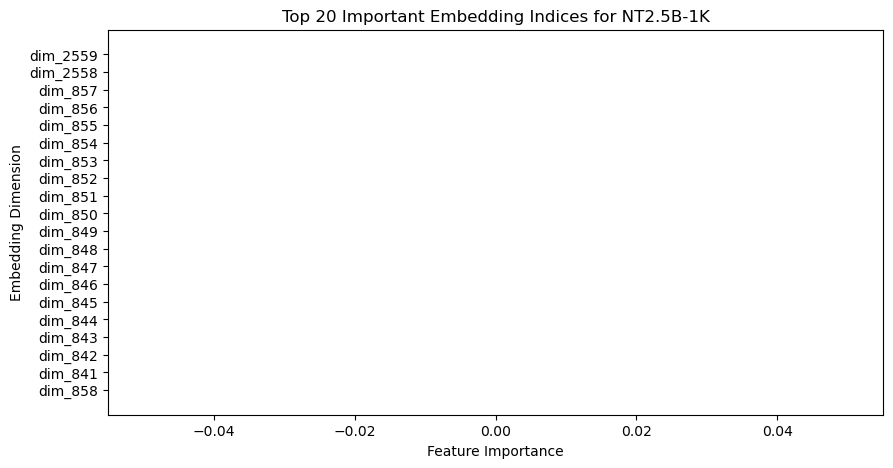


Now starting with: NT500M

Loading data...
Removed 0 rows with NaN values.
Training classifier...
Evaluating model...
Accuracy: 74.83081283135033 %
              precision    recall  f1-score   support

      Coding       0.77      0.77      0.77     22147
  Non-coding       0.73      0.72      0.72     18784

    accuracy                           0.75     40931
   macro avg       0.75      0.75      0.75     40931
weighted avg       0.75      0.75      0.75     40931

Plotting feature importance (Random Forest)...


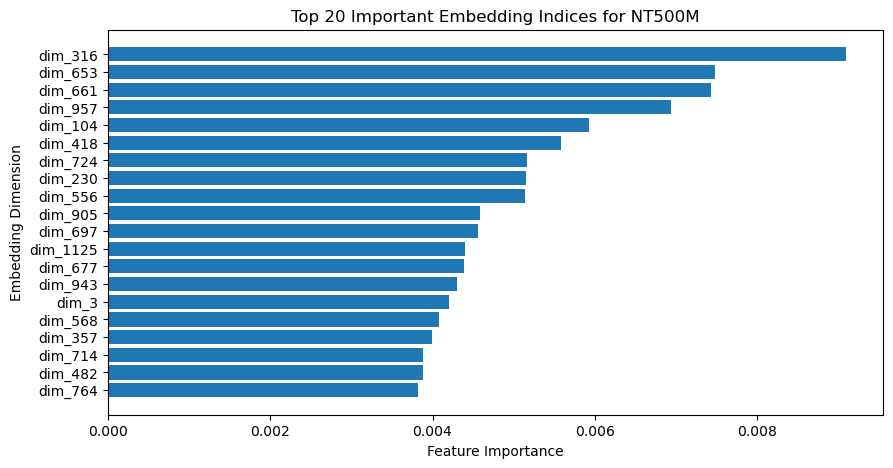

In [16]:
for filename in Path("Coding-NonCoding").glob("*.csv"):    
    main(str(filename), 0.95) #train-test split of 5-95

# One-shot Predictions:


Now starting with: DNABERT-S

Loading data...
Removed 2 rows with NaN values.
Training classifier...
Evaluating model...
Accuracy: 82.00954252034802 %
              precision    recall  f1-score   support

      Coding       0.86      0.66      0.75      1443
  Non-coding       0.80      0.93      0.86      2120

    accuracy                           0.82      3563
   macro avg       0.83      0.79      0.80      3563
weighted avg       0.83      0.82      0.81      3563

Plotting feature importance (Random Forest)...


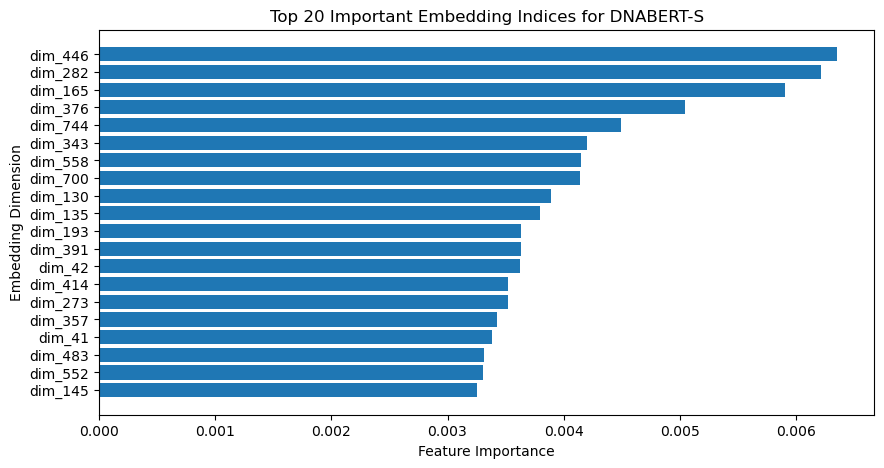

Plotting feature importance (SHAP)...

Now starting with: GenaLM

Loading data...
Removed 2 rows with NaN values.
Training classifier...
Evaluating model...
Accuracy: 90.87847319674431 %
              precision    recall  f1-score   support

      Coding       0.91      0.86      0.88      1443
  Non-coding       0.91      0.94      0.92      2120

    accuracy                           0.91      3563
   macro avg       0.91      0.90      0.90      3563
weighted avg       0.91      0.91      0.91      3563

Plotting feature importance (Random Forest)...


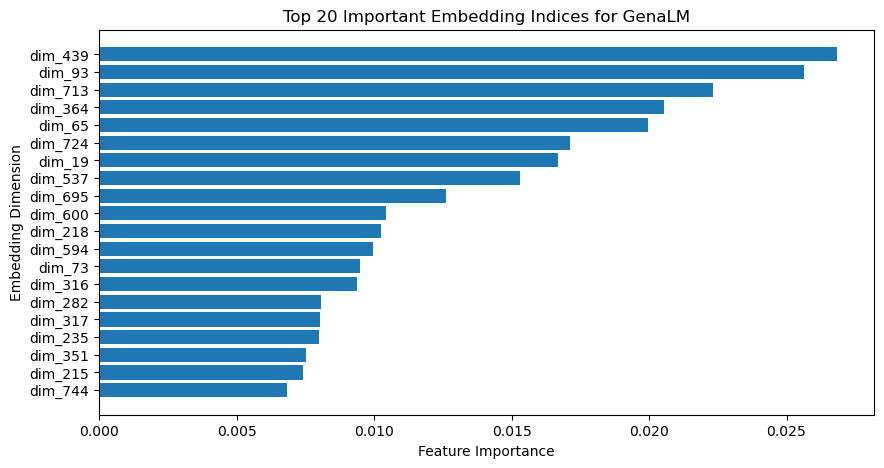

Plotting feature importance (SHAP)...

Now starting with: GPN

Loading data...
Removed 0 rows with NaN values.
Training classifier...
Evaluating model...
Accuracy: 82.80824581874757 %
              precision    recall  f1-score   support

      Coding       0.82      0.85      0.84      3961
  Non-coding       0.84      0.80      0.82      3752

    accuracy                           0.83      7713
   macro avg       0.83      0.83      0.83      7713
weighted avg       0.83      0.83      0.83      7713

Plotting feature importance (Random Forest)...


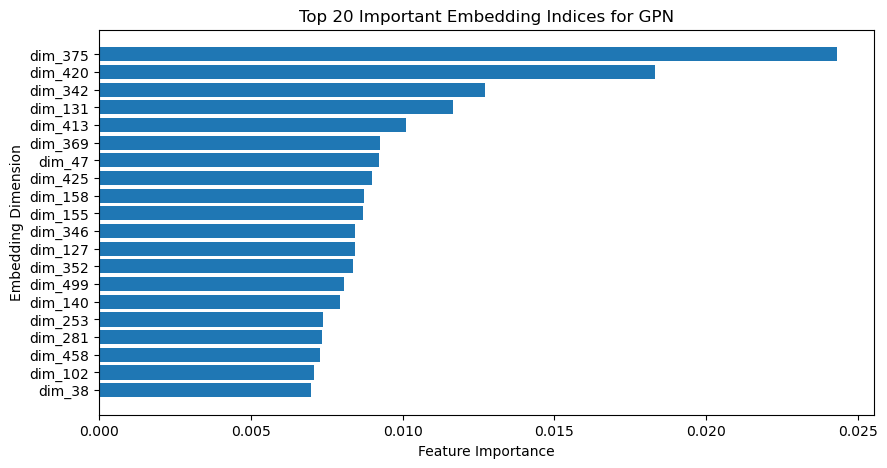

Plotting feature importance (SHAP)...

Now starting with: GROVER

Loading data...
Removed 0 rows with NaN values.
Training classifier...
Evaluating model...
Accuracy: 77.9737727747476 %
              precision    recall  f1-score   support

      Coding       0.81      0.78      0.79      4662
  Non-coding       0.75      0.78      0.77      3955

    accuracy                           0.78      8617
   macro avg       0.78      0.78      0.78      8617
weighted avg       0.78      0.78      0.78      8617

Plotting feature importance (Random Forest)...


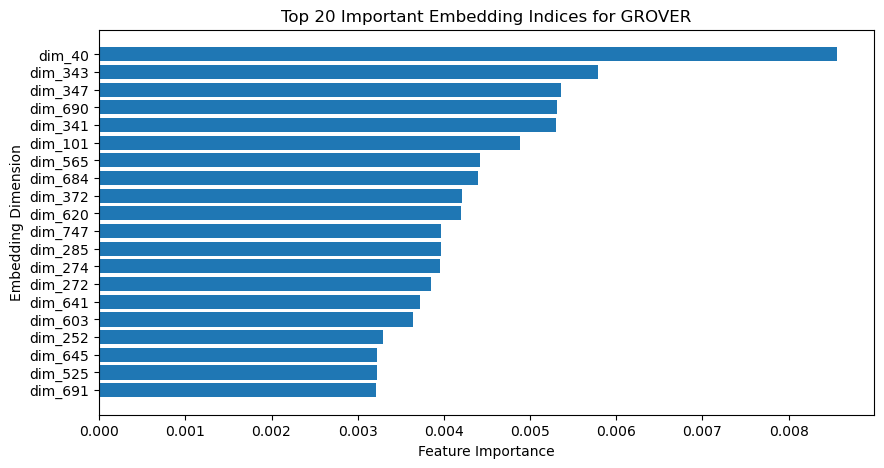

Plotting feature importance (SHAP)...

Now starting with: Hyena-160k

Loading data...
Removed 4 rows with NaN values.
Training classifier...
Evaluating model...
Accuracy: 77.76192946058092 %
              precision    recall  f1-score   support

      Coding       0.79      0.77      0.78      3961
  Non-coding       0.77      0.78      0.77      3751

    accuracy                           0.78      7712
   macro avg       0.78      0.78      0.78      7712
weighted avg       0.78      0.78      0.78      7712

Plotting feature importance (Random Forest)...


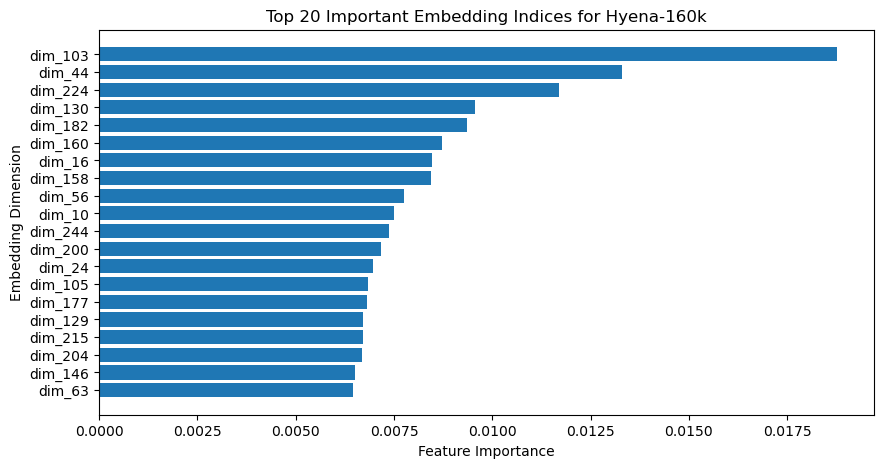

Plotting feature importance (SHAP)...

Now starting with: Hyena-16k

Loading data...
Removed 0 rows with NaN values.
Training classifier...
Evaluating model...
Accuracy: 77.82290820471161 %
              precision    recall  f1-score   support

      Coding       0.79      0.80      0.80      4662
  Non-coding       0.76      0.76      0.76      3955

    accuracy                           0.78      8617
   macro avg       0.78      0.78      0.78      8617
weighted avg       0.78      0.78      0.78      8617

Plotting feature importance (Random Forest)...


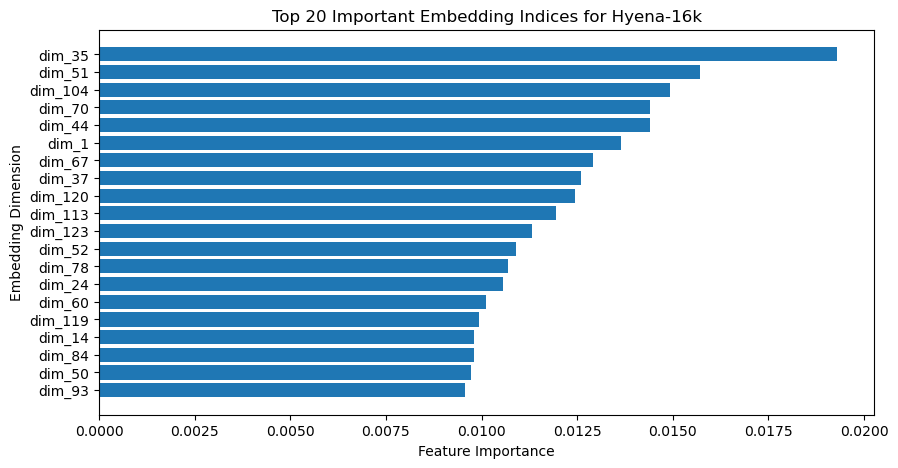

Plotting feature importance (SHAP)...

Now starting with: Hyena-1k

Loading data...
Removed 0 rows with NaN values.
Training classifier...
Evaluating model...
Accuracy: 74.70117210165951 %
              precision    recall  f1-score   support

      Coding       0.77      0.76      0.76      4662
  Non-coding       0.72      0.74      0.73      3955

    accuracy                           0.75      8617
   macro avg       0.75      0.75      0.75      8617
weighted avg       0.75      0.75      0.75      8617

Plotting feature importance (Random Forest)...


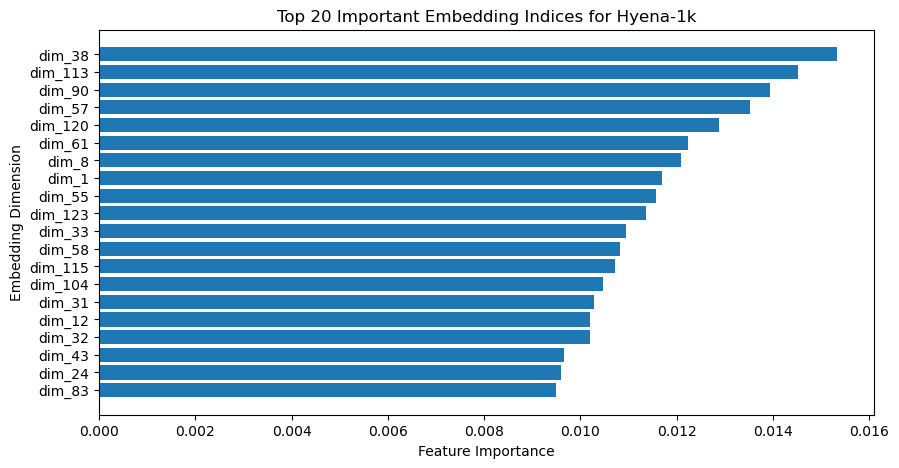

Plotting feature importance (SHAP)...

Now starting with: Hyena-32k

Loading data...
Removed 0 rows with NaN values.
Training classifier...
Evaluating model...
Accuracy: 77.31103332036821 %
              precision    recall  f1-score   support

      Coding       0.78      0.77      0.78      3961
  Non-coding       0.76      0.77      0.77      3752

    accuracy                           0.77      7713
   macro avg       0.77      0.77      0.77      7713
weighted avg       0.77      0.77      0.77      7713

Plotting feature importance (Random Forest)...


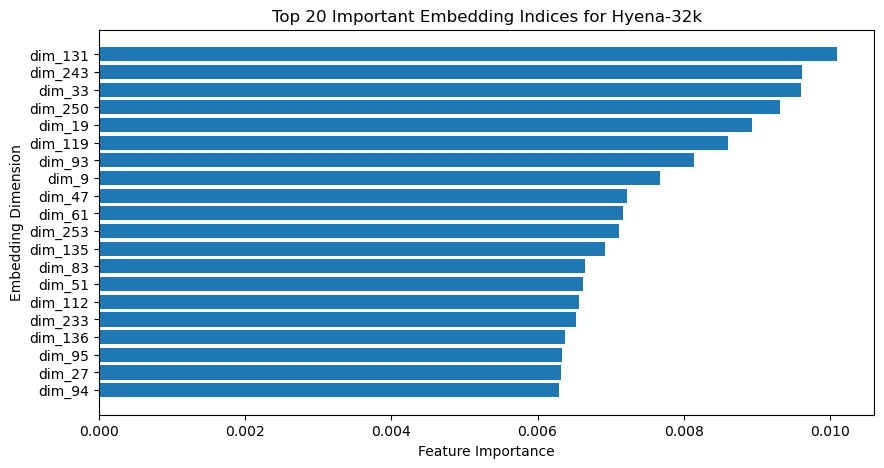

Plotting feature importance (SHAP)...

Now starting with: Hyena-450k

Loading data...
Removed 4 rows with NaN values.
Training classifier...
Evaluating model...
Accuracy: 78.52697095435684 %
              precision    recall  f1-score   support

      Coding       0.80      0.78      0.79      3961
  Non-coding       0.77      0.79      0.78      3751

    accuracy                           0.79      7712
   macro avg       0.79      0.79      0.79      7712
weighted avg       0.79      0.79      0.79      7712

Plotting feature importance (Random Forest)...


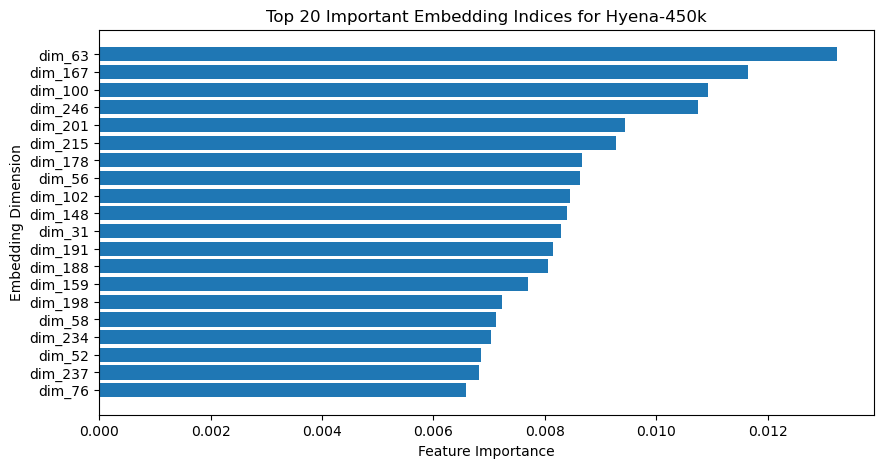

Plotting feature importance (SHAP)...

Now starting with: NT500M

Loading data...
Removed 0 rows with NaN values.
Training classifier...
Evaluating model...
Accuracy: 79.92340721828943 %
              precision    recall  f1-score   support

      Coding       0.83      0.79      0.81      4662
  Non-coding       0.77      0.81      0.79      3955

    accuracy                           0.80      8617
   macro avg       0.80      0.80      0.80      8617
weighted avg       0.80      0.80      0.80      8617

Plotting feature importance (Random Forest)...


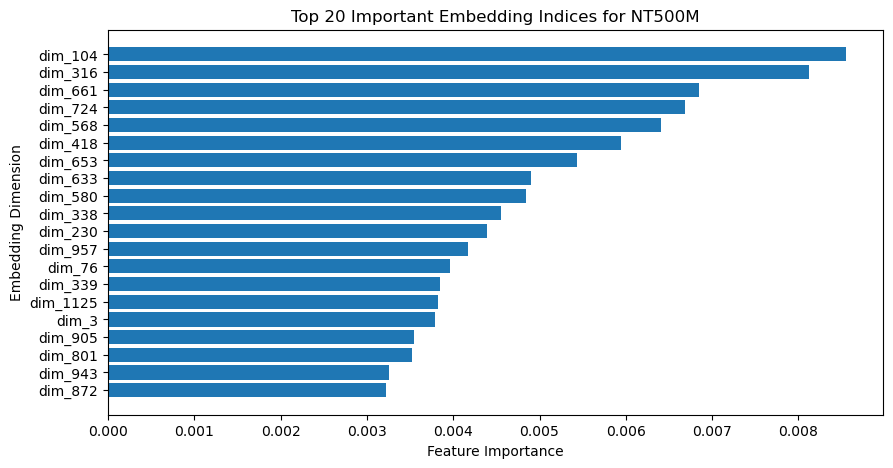

Plotting feature importance (SHAP)...


In [8]:
for filename in Path("Coding-NonCoding").glob("*.csv"):    
    main(str(filename), 0.2) #test split of 80-20

plot distribution of all features' importance; if it's a skewed distribution then choose a meaningful feature 

do the same thing again, then across all of the sequences check if a specific k-mer has a consistent high influence

In [ ]:
paths = []
for filename in Path("Coding-NonCoding").glob("*.csv"):    
    paths.append(str(filename))

if __name__ == "__main__":
    with concurrent.futures.ProcessPoolExecutor(max_workers=20) as executor:
        results = executor.map(main, paths)
        for result in results:
            print(result)


Now starting with: GPN

Loading data...
Removed 0 rows with NaN values.
Training classifier...
Evaluating model...
Accuracy: 81.9690552338145 %
              precision    recall  f1-score   support

      Coding       0.81      0.84      0.83      5942
  Non-coding       0.83      0.80      0.81      5627

    accuracy                           0.82     11569
   macro avg       0.82      0.82      0.82     11569
weighted avg       0.82      0.82      0.82     11569

Plotting feature importance (Random Forest)...


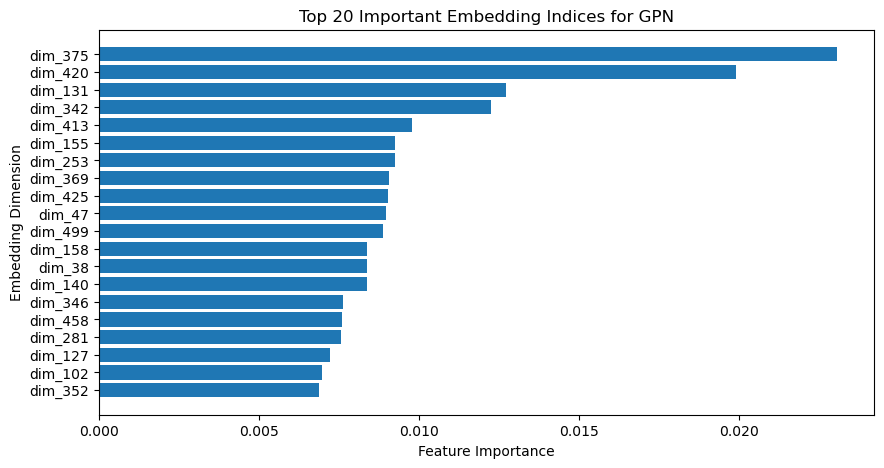


Now starting with: GROVER

Loading data...
Removed 0 rows with NaN values.
Training classifier...
Evaluating model...
Accuracy: 77.23967197895713 %
              precision    recall  f1-score   support

      Coding       0.80      0.77      0.79      6994
  Non-coding       0.74      0.77      0.76      5932

    accuracy                           0.77     12926
   macro avg       0.77      0.77      0.77     12926
weighted avg       0.77      0.77      0.77     12926

Plotting feature importance (Random Forest)...


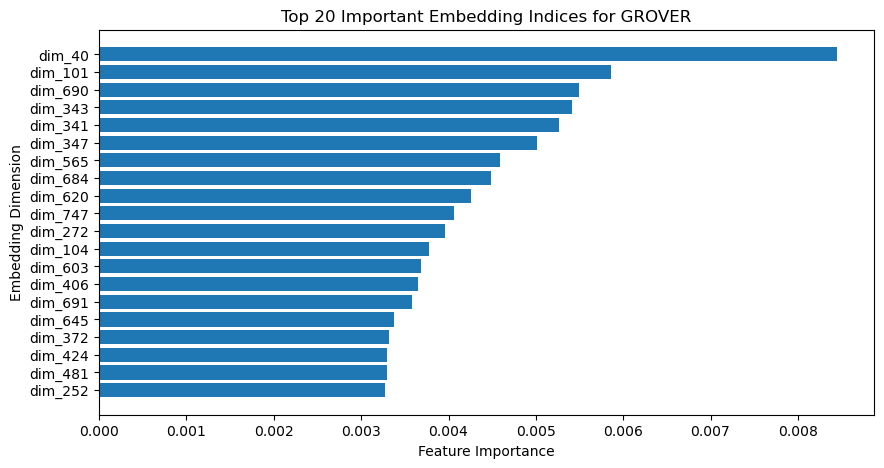


Now starting with: Hyena-160k

Loading data...
Removed 4 rows with NaN values.
Training classifier...
Evaluating model...
Accuracy: 77.3426694329184 %
              precision    recall  f1-score   support

      Coding       0.78      0.77      0.78      5941
  Non-coding       0.76      0.77      0.77      5627

    accuracy                           0.77     11568
   macro avg       0.77      0.77      0.77     11568
weighted avg       0.77      0.77      0.77     11568

Plotting feature importance (Random Forest)...


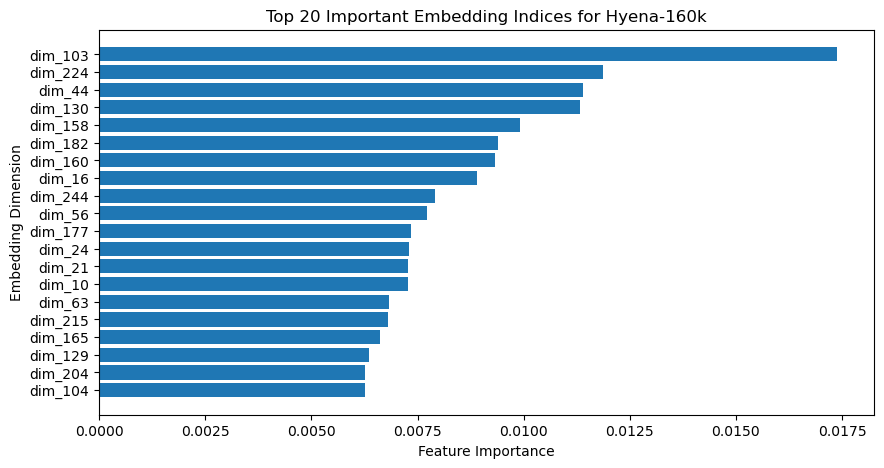


Now starting with: Hyena-16k

Loading data...
Removed 0 rows with NaN values.
Training classifier...
Evaluating model...
Accuracy: 77.69611635463407 %
              precision    recall  f1-score   support

      Coding       0.79      0.80      0.79      6994
  Non-coding       0.76      0.75      0.76      5932

    accuracy                           0.78     12926
   macro avg       0.78      0.77      0.78     12926
weighted avg       0.78      0.78      0.78     12926

Plotting feature importance (Random Forest)...


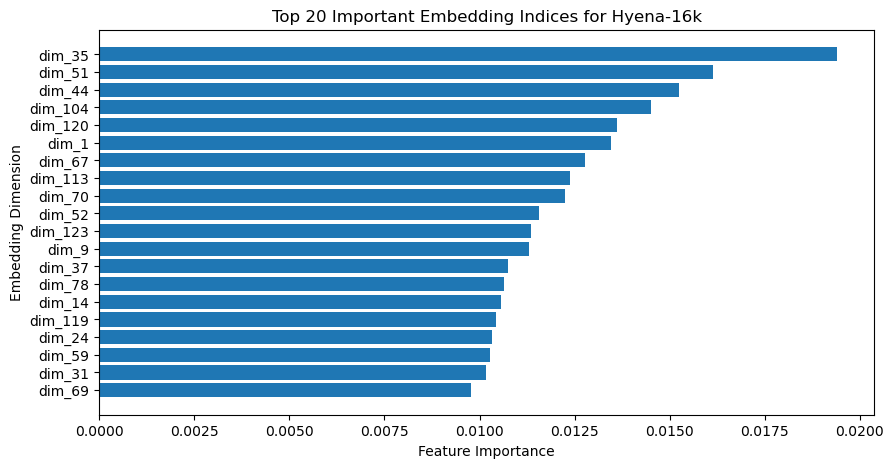


Now starting with: Hyena-1k

Loading data...
Removed 0 rows with NaN values.
Training classifier...
Evaluating model...
Accuracy: 73.81247098870493 %
              precision    recall  f1-score   support

      Coding       0.76      0.75      0.76      6994
  Non-coding       0.71      0.72      0.72      5932

    accuracy                           0.74     12926
   macro avg       0.74      0.74      0.74     12926
weighted avg       0.74      0.74      0.74     12926

Plotting feature importance (Random Forest)...


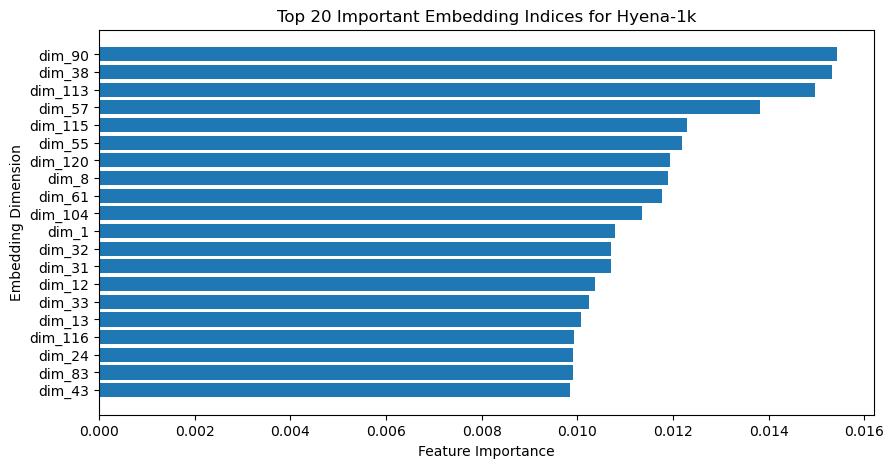


Now starting with: Hyena-450k

Loading data...
Removed 4 rows with NaN values.
Training classifier...
Evaluating model...
Accuracy: 78.25899031811895 %
              precision    recall  f1-score   support

      Coding       0.80      0.78      0.79      5941
  Non-coding       0.77      0.79      0.78      5627

    accuracy                           0.78     11568
   macro avg       0.78      0.78      0.78     11568
weighted avg       0.78      0.78      0.78     11568

Plotting feature importance (Random Forest)...


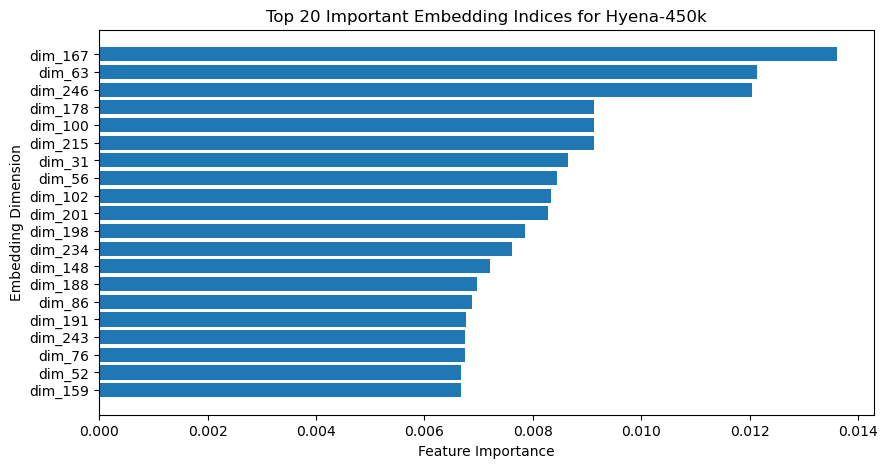


Now starting with: NT500M

Loading data...
Removed 0 rows with NaN values.
Training classifier...
Evaluating model...
Accuracy: 80.017019959771 %
              precision    recall  f1-score   support

      Coding       0.83      0.79      0.81      6994
  Non-coding       0.77      0.81      0.79      5932

    accuracy                           0.80     12926
   macro avg       0.80      0.80      0.80     12926
weighted avg       0.80      0.80      0.80     12926

Plotting feature importance (Random Forest)...


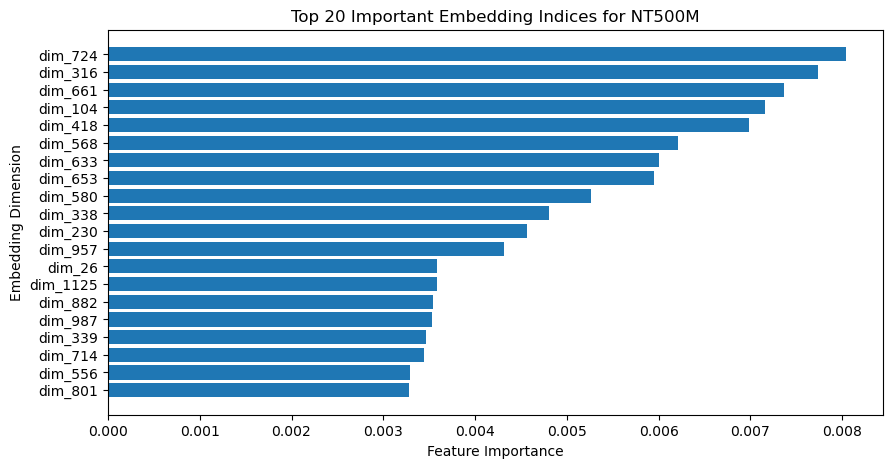

In [ ]:
for filename in Path("Coding-NonCoding").glob("*.csv"):        
    main(str(filename), 0.3) #training-test split of 70-30